# Detecting Malicious Insider Emails via Metadata and Semantic Deviations from Historical Baselines - Code

### Jackson Cramer

## 1. Package Loading

In [1]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
import csv
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_curve
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy.stats import pearsonr

/usr/local/Caskroom/miniconda/base/envs/cert-project/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## 2. Email Data Loading

In [2]:
# Load data into a dataframe by opening zip file

with zipfile.ZipFile("../Data/emails_lloyds.zip", "r") as z:
    with z.open("email.csv") as f:
        email_df = pd.read_csv(f)

## 3. Email Data Preprocessing

In [33]:
# Convert date column to datetime type
email_df['date'] = pd.to_datetime(email_df['date'], format='%m/%d/%Y %H:%M:%S')

# Add number of attachments feature, with each attachment separated by ";"
email_df['num_attachments'] = email_df['attachments'].fillna('').apply(
    lambda x: len(x.split(';')) if x != '' else 0)
# Remove old attachments column - no longer needed
email_df = email_df.drop(columns=["attachments"])

# Add number of recipients feature - include to, cc, and bcc, with each recipient separated by ";"
def count_recipients(x):
        # x: semicolon-separated recipient string from a to/cc/bcc cell
    return len(x.split(';')) if pd.notna(x) and x != '' else 0
email_df['num_recipients'] = (
    email_df['to'].apply(count_recipients)
    + email_df['cc'].apply(count_recipients)
    + email_df['bcc'].apply(count_recipients))

# Remove "View" emails
email_df = email_df[email_df["activity"]!="View"]
# Remove old activity column - no longer needed
email_df = email_df.drop(columns=["activity"])

# Add day of week feature
email_df["day_of_week"] = email_df["date"].dt.day_name()

# Add external sender flag - external means user does not have dtaa.com in their name
email_df["external_sender"] = email_df["from"].str.split("@").str[-1] != "dtaa.com"

# Add external recipient flag - include to, cc, and bcc recipients, external defined above
def external_flag(col):
        # col: name of a recipient column ('to', 'cc', or 'bcc') in email_df
    return email_df[col].str.split(";").apply(lambda addresses: any(a.split("@")[-1] != "dtaa.com" for a in addresses) if isinstance(addresses, list) else False)
email_df["external_recipient"] = external_flag("to") | external_flag("cc") | external_flag("bcc")

In [4]:
# Add LDAP information (specifically department) to each user

# Load LDAP files (department info), skipping months outside study period
ldap_dfs = []
with zipfile.ZipFile("../Data/emails_lloyds.zip", "r") as z:
    ldap_files = sorted([n for n in z.namelist() if n.startswith("LDAP/") and n.endswith(".csv") and "2009-12" not in n]) # Leave out 2009-2012
    for name in ldap_files:
        with z.open(name) as f:
            temp = pd.read_csv(f)
            temp['year_month'] = name.split('/')[-1].replace('.csv', '')
            ldap_dfs.append(temp)
ldap_df = pd.concat(ldap_dfs, ignore_index=True)

# Match each email to the sender's department for that year-month
email_df['year_month'] = email_df['date'].dt.strftime('%Y-%m')
ldap_df = ldap_df.rename(columns={'user_id': 'user'})
# Join department to email_df
email_df = email_df.merge(
    ldap_df[['user', 'year_month', 'department']],
    on=['user', 'year_month'],
    how='left')
# Remove year_month - no longer needed
email_df = email_df.drop(columns=['year_month'])

## 4. Answers Data Preparation

Note: all observations in the answers dataset represent malicious acts

In [2]:
# Locate answers files with "email" type events

email_files = []
for file in range(1,6):
    types = []
    with open(f"../Data/r6.2-{file}.csv", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            types.append(row[0])
    if 'email' in Counter(types):
        email_files.append(file)
email_files

[2, 3, 4]

In [3]:
# Extract "email" type rows from files 2, 3, 4 into separate dataframes

def extract_email_rows(filepath):
        # filepath: path to a r6.2 file
    rows = []
    with open(filepath, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if row[0] == "email":
                rows.append(row[1:])
    return rows

# Specify columns to retain
email_cols = ["id", "date", "user", "pc", "to", "cc", "bcc",
              "from", "activity", "size", "attachments", "content_flag", "content"]

# Keep as separate dataframes (not concatenated yet) so each file can be checked individually before merging
rows_2 = extract_email_rows("../Data/r6.2-2.csv")
ans_2_email_df = pd.DataFrame(rows_2, columns=email_cols[:len(rows_2[0])])

rows_3 = extract_email_rows("../Data/r6.2-3.csv")
ans_3_email_df = pd.DataFrame(rows_3, columns=email_cols[:len(rows_3[0])])

rows_4 = extract_email_rows("../Data/r6.2-4.csv")
ans_4_email_df = pd.DataFrame(rows_4, columns=email_cols[:len(rows_4[0])])

In [4]:
# Remove "View" emails - as was done with email_df

ans_2_email_df = ans_2_email_df[ans_2_email_df["activity"] == "Send"].reset_index(drop=True).drop(columns=["activity"])
ans_3_email_df = ans_3_email_df[ans_3_email_df["activity"] == "Send"].reset_index(drop=True).drop(columns=["activity"])
ans_4_email_df = ans_4_email_df[ans_4_email_df["activity"] == "Send"].reset_index(drop=True).drop(columns=["activity"])

In [5]:
# Extract the id's of all malicious emails for subsequent investigation

malicious_ids = []
malicious_scenario = {} # Keep a dictionary with what dataset the malicious emails came from (aka which scenario)

for scenario, data in [(2, ans_2_email_df), (3, ans_3_email_df), (4, ans_4_email_df)]:
    for email_id in data["id"]:
        malicious_ids.append(email_id)
        malicious_scenario[email_id] = scenario

## 5. Creation of Semantic Embeddings

In [9]:
# Load pre-trained embedding model - 'all-MiniLM-L6-v2'

model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/Caskroom/miniconda/base/envs/cert-project/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
# Randomly subsample users for efficiency, but stratify to make sure all malicious emails are retained

# Find every user linked to at least one malicious email
malicious_email_df = email_df[email_df["id"].isin(malicious_ids)]
malicious_users = malicious_email_df["user"].unique()

# Keep those users' full email history
malicious_user_emails = email_df[email_df["user"].isin(malicious_users)]

# Sample a further set of (50) clean users, seeded for reproducibility
clean_users = email_df.loc[~email_df["user"].isin(malicious_users), "user"].unique()
n_clean_users_to_sample = 50
sampled_clean_users = np.random.RandomState(123).choice(clean_users, size=min(n_clean_users_to_sample, len(clean_users)), replace=False)
clean_user_emails = email_df[email_df["user"].isin(sampled_clean_users)]

# Combine clean and malicious users into our working subset
subset_df = pd.concat([malicious_user_emails, clean_user_emails], ignore_index=True)

In [22]:
# Embedding (commented out as it is slow. Re-run only if subset_df changes or need to re-create it)

# contents = subset_df["content"].tolist() # Obtain raw emails to embed
# embeddings = model.encode(contents, batch_size=250, show_progress_bar=True) # Carry out embedding, with batch_size=250 for efficiency
# subset_df = subset_df.reset_index(drop=True)  # Ensure index matches embeddings order
# subset_df["embedding"] = list(embeddings) # Add embeddings column to dataset
# subset_df.to_parquet("../Data/subset_df_embedded.parquet") # Write dataset to compact parquet file to allow us not to re-run every time

# Load pre-computed embeddings instead
subset_df = pd.read_parquet("../Data/subset_df_embedded.parquet")

## 6. Semantic Deviation Feature Creation

In [12]:
# Build the clean reference pool, with malicious emails removed
clean_email_df_all = (
    subset_df[~subset_df["id"].isin(malicious_ids)]
    .sort_values("date")          # Sort by date, needed for searchsorted later
    .reset_index(drop=True))
# Extract dates of all clean emails
clean_dates_all = clean_email_df_all["date"].values
# Extract embeddings of all clean emails
clean_embeddings_all = np.stack(clean_email_df_all["embedding"].values)

# Normalise embeddings so cosine similarity is a dot product from here on
clean_norms_all = clean_embeddings_all / np.linalg.norm(clean_embeddings_all, axis=1, keepdims=True)

# Define function that calculates cosine distance between two normalised vectors
def fast_cosine_dist(x_norm, centroid_norm):
        # x_norm: normalised embedding of one email
        # centroid_norm: normalised baseline centroid
    return 1 - (x_norm @ centroid_norm)

# Define function that scores an email against the baseline, and return None if the baseline is too small
def score_against_baseline(baseline_norms, x_norm, min_baseline=40, std_floor=0.02):
        # baseline_norms: normalised embeddings making up the baseline
        # x_norm: normalised embedding of the email being scored
        # min_baseline: minimum baseline size required to return a score
        # std_floor: minimum allowed std
    n = baseline_norms.shape[0]
    if n < min_baseline:
        return None

    # Calculate centroid -> the average embedding of the baseline
    centroid = baseline_norms.mean(axis=0)
    centroid_norm = centroid / np.linalg.norm(centroid) # Normalise centroid

    dist = 1 - (x_norm @ centroid_norm) # Cosine distance of this email from the baseline centroid
    baseline_dists = 1 - (baseline_norms @ centroid_norm) # Cosine distance of each baseline email from the centroid, for comparison

    # Standardise distance against baseline's mean and spread
    mu = baseline_dists.mean()
    std = max(baseline_dists.std(), std_floor)  # Set floor to avoid inflated z on homogenous baselines

    # Return raw distance, z-score, and baseline size
    return dist, (dist - mu) / std, n

# Define function that scores every email of one user against a backward-looking baseline.
def rolling_deviation(group, clean_email_df, clean_dates_all, clean_norms_all,
                      mode="window", window=pd.Timedelta(days=30), min_baseline=40):
        # group: one user's emails
        # clean_email_df: all non-malicious emails
        # clean_dates_all: dates column of clean_email_df, as an array
        # clean_norms_all: normalised embeddings of clean_email_df
        # mode: "window" (trailing # days) or "expanding" (all history so far)
        # window: size of the trailing window when mode="window"
        # min_baseline: same as defined before
    # Sort this user's emails chronologically and extrat dates
    group = group.sort_values("date").reset_index(drop=True)
    dates = group["date"].values
    embeddings = np.stack(group["embedding"].values)  # Represent this user's embeddings as an (n, d) matrix
    norms = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)  # Unit-normalise for cosine dist

    is_malicious = group["id"].isin(malicious_ids).values  # Flag if email is malicious
    department = group["department"].iloc[0] # Extract department of email
    dept_mask_all = clean_email_df["department"].values == department  # Mask the clean pool for this dept

    n = len(group)
    deviations = np.full(n, np.nan)          # Raw cosine distance per email
    deviations_z = np.full(n, np.nan)        # Standardised score per email
    n_baseline_emails = np.zeros(n, dtype=int)  # Size of baseline actually used
    labels = np.array(["insufficient_data"] * n, dtype=object)  # Which tier was used - default label is insufficient_data, overwritten once a tier succeeds

    # Score each email against a baseline built only from data before it
    for i in range(n):
        d = dates[i]

        # Fallback tiers: personal -> department -> global
        # Use lambda functions so a tier is only built if the ones above it didn't have enough data
        # Window baseline specification
        if mode == "window":
            tiers = [
                (lambda: norms[(dates < d) & (dates >= d - window) & (~is_malicious)], "personal_window"),
                (lambda: clean_norms_all[dept_mask_all & (clean_dates_all < d) & (clean_dates_all >= d - window)], "dept_window"),
                (lambda: clean_norms_all[(clean_dates_all < d) & (clean_dates_all >= d - window)], "global_window"),
                (lambda: clean_norms_all[clean_dates_all < d], "global_alltime")]
        # Expanding baseline specification
        else:
            tiers = [
                (lambda: norms[(dates < d) & (~is_malicious)], "personal_expanding"),
                (lambda: clean_norms_all[dept_mask_all & (clean_dates_all < d)], "dept_expanding"),
                (lambda: clean_norms_all[clean_dates_all < d], "global_expanding")]

        # Try each tier in order, and use the first one with enough emails
        best_n = 0
        for get_baseline, label in tiers:
            baseline_norms = get_baseline()
            best_n = max(best_n, baseline_norms.shape[0])
            result = score_against_baseline(baseline_norms, norms[i], min_baseline)
            if result is not None:
                deviations[i], deviations_z[i], n_baseline_emails[i] = result
                labels[i] = label
                break
        else:
            n_baseline_emails[i] = best_n  # If no tier had enough data, keep the closest attempt for reference

    # Attach results back onto this user's rows
    group["semantic_deviation"] = deviations
    group["semantic_deviation_z"] = deviations_z
    group["n_baseline_emails"] = n_baseline_emails
    group["baseline_label"] = labels
    return group

# Define function that scores every email against global baseline
def compute_global_mode(full_df, clean_dates_all, clean_norms_all,
                        min_baseline=40, refresh_factor=1.25, std_floor=0.02):
        # full_df: all emails (malicious + clean) to be scored
        # clean_dates_all: dates column of the clean pool, as an array
        # clean_norms_all: normalised embeddings of the clean pool
        # min_baseline: same as defined before
        # refresh_factor: how much the baseline must grow before mu/std are recomputed
        # std_floor: minimum allowed std
    # Sort this user's emails chronologically and extract dates
    df = full_df.sort_values("date").reset_index(drop=True)
    dates = df["date"].values
    embeddings = np.stack(df["embedding"].values) # Extract embeddings
    norms = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)  # Unit-normalise for cosine dist

    # Calculate cumulative sum sum of clean embeddings for efficiency
    clean_cumsum = np.cumsum(clean_norms_all, axis=0)  

    deviations = np.full(len(df), np.nan)          # Raw cosine distance per email
    deviations_z = np.full(len(df), np.nan)        # Standardised score per email
    n_baseline_emails = np.zeros(len(df), dtype=int)  # Size of baseline used
    labels = np.array(["insufficient_data"] * len(df), dtype=object) # Which tier was used - default label is insufficient_data, overwritten once a tier succeeds

    saved_mu, saved_std, saved_idx = None, None, -1  # Baseline's mean and std distance, and the size (m) they were last computed at

    # Loop through each email in df in chronological order
    for i in range(len(df)):
        m = np.searchsorted(clean_dates_all, dates[i], side="left")  # # of clean emails before this one
        if m < min_baseline:
            n_baseline_emails[i] = m  # If not enough history yet - leave this row as NaN
            continue

        # Calculate cumulative centroid of all clean emails up to this point
        centroid = clean_cumsum[m - 1] / m
        centroid_norm = centroid / np.linalg.norm(centroid)
        dist = fast_cosine_dist(norms[i], centroid_norm)

        # For efficiency, only recompute mu/std occasionally, according to refresh_factor
        if saved_std is None or m >= saved_idx * refresh_factor:
            baseline_dists = 1 - (clean_norms_all[:m] @ centroid_norm)
            saved_mu = baseline_dists.mean()
            saved_std = max(baseline_dists.std(), std_floor)
            saved_idx = m

        # Attach this email's distance, z-score, baseline size, and tier label
        deviations[i] = dist
        deviations_z[i] = (dist - saved_mu) / saved_std
        n_baseline_emails[i] = m
        labels[i] = "global_alltime"

    # Attach results back onto the full dataframe
    df["semantic_deviation"] = deviations
    df["semantic_deviation_z"] = deviations_z
    df["n_baseline_emails"] = n_baseline_emails
    df["baseline_label"] = labels
    return df


# Run all three baseline definitions and save semantic deviation scores for each
semantic_results = {}
# First do window and expanding as they share the same per-user scoring function
for mode in ["window", "expanding"]:
    df = subset_df.sort_values(["user", "date"]).groupby("user", group_keys=False).apply(
        rolling_deviation,
        clean_email_df=clean_email_df_all,
        clean_dates_all=clean_dates_all,
        clean_norms_all=clean_norms_all,
        mode=mode).reset_index(drop=True)
    semantic_results[mode] = df

# Now use global baseline
semantic_results["global"] = compute_global_mode(subset_df, clean_dates_all, clean_norms_all)

# Create dataframes with semantic deviations for each baseline type
result_df_window = semantic_results["window"] 
result_df_expanding = semantic_results["expanding"]
result_df_global = semantic_results["global"] 

# Re-attach "user" column as it is dropped via above code
result_df_window = result_df_window.merge(subset_df[["id", "user"]], on="id", how="left")
result_df_expanding = result_df_expanding.merge(subset_df[["id", "user"]], on="id", how="left")

In [13]:
# Encode day of week feature cyclically to work appropriately with models

day_map = {"Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6}
subset_df["day_of_week_num"] = subset_df["day_of_week"].map(day_map)
# Put encoded sine and cosine day of week features into subset_df
subset_df["day_sin"] = np.sin(2 * np.pi * subset_df["day_of_week_num"] / 7)
subset_df["day_cos"] = np.cos(2 * np.pi * subset_df["day_of_week_num"] / 7)
# Merge day_sin/day_cos into the three result dataframes
merge_cols = ["id", "day_sin", "day_cos"]
dfs = {
    "window": result_df_window,
    "expanding": result_df_expanding,
    "global": result_df_global}
for name, df in dfs.items():
    df = df.drop(columns=["day_sin", "day_cos"], errors="ignore") # Avoid duplicate columns if re-run
    dfs[name] = df.merge(subset_df[merge_cols], on="id", how="left")
result_df_window = dfs["window"]
result_df_expanding = dfs["expanding"]
result_df_global = dfs["global"]

# Specify metadata features to use in subsequent modeling
feature_cols = ["size", "num_attachments", "num_recipients", "external_recipient", "day_sin", "day_cos", "external_sender"]

## 7. Anomaly Scoring by Four Models

### Model 1: Z-Score

In [14]:
# Specify clean (non-malicious) population, used for global/dept fallback baselines
clean_df_sorted = subset_df[~subset_df["id"].isin(malicious_ids)].sort_values("date").reset_index(drop=True)
global_dates = clean_df_sorted["date"].values

# Standardise features against the clean population before scoring
_raw = clean_df_sorted[feature_cols].astype(float).values
global_mu = _raw.mean(axis=0)
global_sigma = _raw.std(axis=0)
global_sigma[global_sigma <= 0] = 1.0  # Avoid divide-by-zero for a feature with no variance
global_feats = (_raw - global_mu) / global_sigma


# Define function that computes the std of each feature over the first k clean emails
def prior_global_scale(k):
        # k: number of prior clean emails to compute the scale over
    mean = global_cumsum[k - 1] / k
    var = np.clip(global_cumsumsq[k - 1] / k - mean ** 2, 0, None)  # Calculate variance clipped at 0 to guard against rounding error going negative
    return np.maximum(np.sqrt(var), 1e-8)   # Ensure never exactly zero to avoid divide-by-zero


std_floor = 0.05  # z-score std floor, as a fraction of the global scale

# Specify directional columns
directional_cols = {"size", "num_attachments", "num_recipients"}
is_directional = np.array([c in directional_cols for c in feature_cols])

# Define function that converts a raw z-score into its final anomaly-scoring form,
# with one-sided (clip at 0) for directional features, two-sided |z| for the rest
def finalise_z(z):
        # z: raw z-score(s) for one or more features
    return np.where(is_directional, np.clip(z, 0, None), np.abs(z))

# Calculate cumulative sums for efficiency
global_cumsum = np.cumsum(global_feats, axis=0)
global_cumsumsq = np.cumsum(global_feats ** 2, axis=0)

# Same with cumulative sums, but by department
dept_cum = {}
# Loop through each department's clean emails
for dept, sub in clean_df_sorted.groupby("department"): 
    sub_feats = (sub[feature_cols].astype(float).values - global_mu) / global_sigma # this department's standardised features
    dept_cum[dept] = {
        "dates": sub["date"].values,
        "feats": sub_feats,
        "cumsum": np.cumsum(sub_feats, axis=0),
        "cumsumsq": np.cumsum(sub_feats ** 2, axis=0)}


# Define function that z-scores an email's features against a baseline, returning None if too small
def score_tier(feats_baseline, x, floor, min_baseline=40):
        # feats_baseline: standardised features for the emails making up this baseline
        # x: standardised features of the email being scored
        # floor: minimum std allowed (prevents inflated z on a homogenous baseline)
        # min_baseline: minimum emails for current tier to be used, otherwise move onto next
    n = feats_baseline.shape[0]
    if n < min_baseline:
        return None
    mean = feats_baseline.mean(axis=0)
    std = np.maximum(feats_baseline.std(axis=0), floor)
    return finalise_z((x - mean) / std), n

# Define function that does the same as score_tier, but using precomputed cumulative sums
def score_tier_cumsum(cumsum, cumsumsq, k, x, floor, min_baseline=40):
        # cumsum/cumsumsq: running sums for the population this baseline is drawn from
        # k: number of prior rows to use as the baseline
        # x, min_baseline, floor: same as defined previously
    if k < min_baseline:
        return None
    mean = cumsum[k - 1] / k
    std = np.maximum(np.sqrt(np.clip(cumsumsq[k - 1] / k - mean ** 2, 0, None)), floor)
    return finalise_z((x - mean) / std), k


# Define function that z-scores every email of one user's metadata features against its historical baseline
def rolling_zscore(group, mode="window", window=pd.Timedelta(days=30), min_baseline=40):
        # group: one user's emails
        # mode: baseline mode (window, expanding, global)
        # window: trailing window size when mode="window"
        # min_baseline: same as defined previously
    group = group.sort_values("date").reset_index(drop=True)
    dates = group["date"].values
    # Standardised with the same mu/sigma as the population baselines, so scores are comparable
    feats = (group[feature_cols].astype(float).values - global_mu) / global_sigma
    row_ok = ~np.isnan(feats).any(axis=1)   # Flag rows where a feature is missing
    is_malicious = group["id"].isin(malicious_ids).values
    department = group["department"].iloc[0]

    # Extract this user's department baseline precomputed cumulative sums
    dept_dates = dept_cum[department]["dates"]
    dept_feats = dept_cum[department]["feats"]
    dept_cumsum = dept_cum[department]["cumsum"]
    dept_cumsumsq = dept_cum[department]["cumsumsq"]

    z_scores = np.full((len(group), len(feature_cols)), np.nan)  # One z-score per feature per email
    n_baseline_emails = np.zeros(len(group), dtype=int)          # Size of baseline used per email
    labels = np.array(["insufficient_data"] * len(group), dtype=object)  # Label which tier was used, with default of insufficient_data

    # Loop through each email in this user's group, chronologically
    for i in range(len(group)):
        if not row_ok[i]:   # Can't score a row with a NaN feature - skip it and label why
            labels[i] = "missing_features"
            continue
        d = dates[i]
        num_clean_prior = np.searchsorted(global_dates, d, side="left")  # # of clean emails globally before this one
        # Ensure floor grows with size of global baseline
        floor = std_floor * prior_global_scale(num_clean_prior) if num_clean_prior >= min_baseline else np.zeros(len(feature_cols))

        # Score according to global baseline
        if mode == "global":
            # Only one tier with this baseline, so score against the whole org's history up to this point
            k = np.searchsorted(global_dates, d, side="left")
            result = score_tier_cumsum(global_cumsum, global_cumsumsq, k, feats[i], floor, min_baseline)
            if result is not None:
                z_scores[i], n_baseline_emails[i] = result  # Score email
                labels[i] = "global_alltime" # Label its tier
            else:
                n_baseline_emails[i] = k  # Not enough global history yet - record it, leave z-score as NaN
            continue

        # Score according to expanding baseline
        if mode == "expanding":
            personal_mask = (dates < d) & (~is_malicious)  # Refine to this user's own prior clean emails
            k_dept = np.searchsorted(dept_dates, d, side="left")  # # of clean emails in dept before this one
            num_clean_prior = np.searchsorted(global_dates, d, side="left")
            
            # Score according to fall back structure: personal -> dept -> global, and label which tier was reached
            result = score_tier(feats[personal_mask], feats[i], floor, min_baseline)
            label = "personal_expanding"
            if result is None:
                result = score_tier_cumsum(dept_cumsum, dept_cumsumsq, k_dept, feats[i], floor, min_baseline)
                label = "dept_expanding"
            if result is None:
                result = score_tier_cumsum(global_cumsum, global_cumsumsq, num_clean_prior, feats[i], floor, min_baseline)
                label = "global_expanding"
            if result is not None:
                z_scores[i], n_baseline_emails[i] = result
                labels[i] = label
            else:
                n_baseline_emails[i] = num_clean_prior  # No tier reached - record closest attempt for reference and score as NaN
            continue

        # Score according to 30 day window baseline: personal 30 days, department 30 days, global 30 days, global all time, and label which tier was reached
        personal_window_mask = (dates < d) & (dates >= d - window) & (~is_malicious)
        dept_window_mask = (dept_dates < d) & (dept_dates >= d - window)
        global_window_mask = (global_dates < d) & (global_dates >= d - window)
        global_alltime_mask = global_dates < d
        result = score_tier(feats[personal_window_mask], feats[i], floor, min_baseline)
        label = "personal_window"
        if result is None:
            result = score_tier(dept_feats[dept_window_mask], feats[i], floor, min_baseline)
            label = "dept_window"
        if result is None:
            result = score_tier(global_feats[global_window_mask], feats[i], floor, min_baseline)
            label = "global_window"
        if result is None:
            result = score_tier(global_feats[global_alltime_mask], feats[i], floor, min_baseline)
            label = "global_alltime"
        if result is not None:
            z_scores[i], n_baseline_emails[i] = result
            labels[i] = label
        else:
            n_baseline_emails[i] = global_alltime_mask.sum()

    # Attach one z-score column per feature, plus baseline size and tier label
    for j, col in enumerate(feature_cols):
        group[f"{col}_z"] = z_scores[:, j]
    group["z_n_baseline"] = n_baseline_emails
    group["z_baseline_label"] = labels
    return group

# Specify dataframes to attach scores to
mode_dfs = {
    "window": result_df_window,
    "expanding": result_df_expanding,
    "global": result_df_global}

# Specify the columns that are z-scored
z_cols = [f"{c}_z" for c in feature_cols] + ["semantic_deviation_z_pos"]

z_results = {}
# Loop through each baseline mode and score its resulting dataframe
for mode, df in mode_dfs.items():
    scored = df.sort_values(["user", "date"])
    scored = scored.groupby("user", group_keys=False).apply(rolling_zscore, mode=mode)
    scored = scored.reset_index(drop=True)
    # Make semantic deviation score positive so being closer than usual to the user's own centroid is normal, not anomalous
    scored["semantic_deviation_z_pos"] = scored["semantic_deviation_z"].clip(lower=0)

    # If semantic_deviation_z came back NaN on a row that otherwise scored fine, relabel it as missing_features too
    semantic_missing = scored["semantic_deviation_z"].isna()
    has_valid_label = ~scored["z_baseline_label"].isin(["insufficient_data", "missing_features"])
    scored.loc[semantic_missing & has_valid_label, "z_baseline_label"] = "missing_features"

    # Calculate overall anomaly score as mean across all feature z-scores 
    # skipna=False so a single missing feature makes the whole row NaN rather than averaging over what's left
    scored["anomaly_score_z"] = scored[z_cols].mean(axis=1, skipna=False)
    z_results[mode] = scored

# Create new dataframes with z-scored data
result_df_z_window = z_results["window"]
result_df_z_expanding = z_results["expanding"]
result_df_z_global = z_results["global"]

# Re-attach "user", dropped above
result_df_z_window = result_df_z_window.merge(subset_df[["id", "user"]], on="id", how="left")
result_df_z_expanding = result_df_z_expanding.merge(subset_df[["id", "user"]], on="id", how="left")
result_df_z_global = result_df_z_global.merge(subset_df[["id", "user"]], on="id", how="left")

### Model 2: PCA Reconstruction Error

In [16]:
# Use tqdm to record code progress
tqdm.pandas()

# Specify features to use
raw_feature_cols = ["size", "num_attachments", "num_recipients",
                     "external_recipient", "semantic_deviation_z", "day_sin", "day_cos", "external_sender"]

# Specify global variables for use in subsequent functions
n_components = 5 # Number of principal componenets to retain  
min_baseline = 40 # Minimum rows needed before a PCA model is fit (same as with z-score)
refit_every = 50 # Rows scores before refits under window/expanding
window = pd.Timedelta(days=30) # Days to look-back for window baseline (same as with z-score)

# Define function that fits a PCA model on a baseline, scaling first
def fit_pca(feats_baseline, n_components):
        # feats_baseline: raw (unscaled) features for the emails making up this baseline
        # n_components: number of PCA components to fit
    scaler = StandardScaler().fit(feats_baseline)  # Scale baseline features to prevent domination by large-scale ones (e.g. size)
    k = min(n_components, feats_baseline.shape[0], feats_baseline.shape[1])   # Cap components at whichever is smaller: rows or features available
    pca = PCA(n_components=k).fit(scaler.transform(feats_baseline)) # Fit PCA
    return scaler, pca


# Define function that builds the clean population and department baselines for a given result dataframe
def build_baseline_arrays(df, raw_feature_cols, malicious_ids):
        # df: result dataframe (window/expanding) to build baselines from
        # raw_feature_cols: feature columns to use
        # malicious_ids: email ids to exclude from the clean population
    # Keep only clean, complete emails for use as baselines
    clean_df_sorted = (
        df[~df["id"].isin(malicious_ids)]
        .dropna(subset=raw_feature_cols)  # Exclude incomplete rows as an NaN feature can't inform a baseline
        .sort_values("date")
        .reset_index(drop=True))
    global_dates = clean_df_sorted["date"].values
    global_feats = clean_df_sorted[raw_feature_cols].astype(float).values

    dept_cum = {}
    # Loop through each department's clean emails and store its dates/features
    for dept, sub in clean_df_sorted.groupby("department"):
        dept_cum[dept] = {
            "dates": sub["date"].values,
            "feats": sub[raw_feature_cols].astype(float).values}
    return global_dates, global_feats, dept_cum


# Define function that scores every email of one user by PCA reconstruction error against it baseline
def rolling_pca_recon(group, dept_cum_raw, global_dates_raw, global_feats_raw,
                       raw_feature_cols, malicious_ids, mode="window",
                       window=pd.Timedelta(days=30), n_components=n_components,
                       min_baseline=40, refit_every=50, variance_log=None):
        # group: one user's emails
        # dept_cum_raw/global_dates_raw/global_feats_raw: baseline arrays from build_baseline_arrays
        # raw_feature_cols, malicious_ids, mode, window, n_components, min_baseline: same as defined previously
        # refit_every: how many rows to score before refitting the PCA model
        # variance_log: list to record explained variance of each fit
        # other features same as defined before
    # Sort this user's emails chronologically and pull out raw features
    group = group.sort_values("date").reset_index(drop=True)
    dates = group["date"].values
    X_all = group[raw_feature_cols].astype(float).values
    row_ok = ~np.isnan(X_all).any(axis=1)   # Flag rows where a feature itself is missing
    is_malicious = group["id"].isin(malicious_ids).values
    department = group["department"].iloc[0]
    dept_dates = dept_cum_raw[department]["dates"]
    dept_feats = dept_cum_raw[department]["feats"]

    recon_error = np.full(len(group), np.nan)   # Reconstruction error per email
    n_baseline_emails = np.zeros(len(group), dtype=int)  # Size of baseline used
    labels = np.array(["insufficient_data"] * len(group), dtype=object)  # Which tier was used

    saved_scaler = saved_pca = None # Fhis gets filled in once a PCA model is fit, then reused across rows
    saved_key = None # (label, row index) that the saved fit came from

    # Score each email against a baseline built only from data before it
    for i in range(len(group)): # Loop through each email in this user's group, chronologically
        if not row_ok[i]:
            labels[i] = "missing_features" # If feature is missing, label it and dont score that email
            continue
        d = dates[i]

        # Build the candidate baselines for this email, in fallback order
        # window baseline
        if mode == "window":
            personal_mask = (dates < d) & (dates >= d - window) & (~is_malicious) & row_ok
            dept_mask = (dept_dates < d) & (dept_dates >= d - window)
            global_window_mask = (global_dates_raw < d) & (global_dates_raw >= d - window)
            global_alltime_mask = global_dates_raw < d
            tiers = [
                ("personal_window", X_all[personal_mask]),
                ("dept_window", dept_feats[dept_mask]),
                ("global_window", global_feats_raw[global_window_mask]),
                ("global_alltime", global_feats_raw[global_alltime_mask])]
        # expanding baseline
        else:
            personal_mask = (dates < d) & (~is_malicious) & row_ok
            dept_mask = dept_dates < d
            global_mask = global_dates_raw < d
            tiers = [
                ("personal_expanding", X_all[personal_mask]),
                ("dept_expanding", dept_feats[dept_mask]),
                ("global_expanding", global_feats_raw[global_mask])]

        # Use the first tier with enough rows
        chosen = None
        for label, feats_baseline in tiers:
            n = feats_baseline.shape[0]
            if n < min_baseline:
                continue
            chosen = (label, n, feats_baseline)
            break
        if chosen is None:
            continue  # No tier qualified - leave as NaN, label stays "insufficient_data"

        label, n, feats_baseline = chosen
        labels[i] = label
        n_baseline_emails[i] = n

        # Refit only if the tier changed or refit_every rows have passed since the last fit
        if (saved_pca is None or saved_key is None
                or saved_key[0] != label or (i - saved_key[1]) >= refit_every):
            saved_scaler, saved_pca = fit_pca(feats_baseline, n_components)
            saved_key = (label, i)
            if variance_log is not None:
                variance_log.append(saved_pca.explained_variance_ratio_.sum())

        # Reconstruct this email through the fitted PCA and measure the squared error
        x_scaled = saved_scaler.transform(X_all[i:i + 1])
        x_recon = saved_pca.inverse_transform(saved_pca.transform(x_scaled))
        recon_error[i] = np.sum((x_scaled - x_recon) ** 2)

    # Attach reconstruction error, baseline size, and tier label
    group["pca_recon_error"] = recon_error
    group["pca_n_baseline"] = n_baseline_emails
    group["pca_baseline_label"] = labels
    return group


# Define function that scores every email using global baseline
def compute_global_pca_mode(df, raw_feature_cols, malicious_ids, n_components=n_components,
                             min_baseline=40, refit_factor=1.25, variance_log=None):
        # df: result dataframe to score
        # refit_factor: how much the baseline must grow before the PCA model is refit
        # other features are same as defined previously
    # Sort all emails chronologically and pull out raw features
    df = df.sort_values("date").reset_index(drop=True)
    dates = df["date"].values
    X_all = df[raw_feature_cols].astype(float).values
    row_ok = ~np.isnan(X_all).any(axis=1)  # Flag rows where a feature itself is missing
    is_malicious = df["id"].isin(malicious_ids).values

    # Clean population this baseline is drawn from
    clean_df_sorted = (df[~is_malicious].dropna(subset=raw_feature_cols).sort_values("date").reset_index(drop=True))
    clean_dates = clean_df_sorted["date"].values
    clean_feats = clean_df_sorted[raw_feature_cols].astype(float).values

    recon_error = np.full(len(df), np.nan)         # Reconstruction error per email
    n_baseline_emails = np.zeros(len(df), dtype=int)  # Size of baseline used
    labels = np.array(["insufficient_data"] * len(df), dtype=object)  # Which tier was used

    saved_scaler = saved_pca = None
    saved_fit_count = -1  # Baseline size (k) the saved fit was made at

     # Loop through each email in dataframe, chronologically
    for i in range(len(df)):
        if not row_ok[i]:
            labels[i] = "missing_features" # If have missing features, label it and score email as NaN
            continue
        k = np.searchsorted(clean_dates, dates[i], side="left")  # # of clean emails before this one
        if k < min_baseline:
            n_baseline_emails[i] = k  # Not enough history yet - leave this row as NaN
            continue

        # Refit proportionally, often while the baseline is small, rarely once large
        if saved_pca is None or k >= saved_fit_count * refit_factor:
            saved_scaler, saved_pca = fit_pca(clean_feats[:k], n_components)
            saved_fit_count = k
            if variance_log is not None:
                variance_log.append(saved_pca.explained_variance_ratio_.sum())
        
        # Reconstruct this email through the fitted PCA and measure the squared error
        x_scaled = saved_scaler.transform(X_all[i:i + 1])
        x_recon = saved_pca.inverse_transform(saved_pca.transform(x_scaled))
        recon_error[i] = np.sum((x_scaled - x_recon) ** 2)
        n_baseline_emails[i] = k
        labels[i] = "global_alltime"

    # Attach reconstruction error, baseline size, and tier label
    df["pca_recon_error"] = recon_error
    df["pca_n_baseline"] = n_baseline_emails
    df["pca_baseline_label"] = labels
    return df


# Build baselines separately per mode, as result_df_z_window/expanding have semantic_deviation_z (not present in subset_df)
global_dates_window, global_feats_window, dept_cum_window = build_baseline_arrays(
    result_df_z_window, raw_feature_cols, malicious_ids)
global_dates_expanding, global_feats_expanding, dept_cum_expanding = build_baseline_arrays(
    result_df_z_expanding, raw_feature_cols, malicious_ids)

# Run window and expanding baseline modes
pca_results = {}
variance_logs = {"window": [], "expanding": [], "global": []}

pca_results["window"] = result_df_z_window.sort_values(["user", "date"]).groupby("user", group_keys=False).progress_apply(
    rolling_pca_recon,
    dept_cum_raw=dept_cum_window, global_dates_raw=global_dates_window, global_feats_raw=global_feats_window,
    raw_feature_cols=raw_feature_cols, malicious_ids=malicious_ids, mode="window",
    window=window, n_components=n_components, min_baseline=min_baseline, refit_every=refit_every,
    variance_log=variance_logs["window"]).reset_index(drop=True)

pca_results["expanding"] = result_df_z_expanding.sort_values(["user", "date"]).groupby("user", group_keys=False).progress_apply(
    rolling_pca_recon,
    dept_cum_raw=dept_cum_expanding, global_dates_raw=global_dates_expanding, global_feats_raw=global_feats_expanding,
    raw_feature_cols=raw_feature_cols, malicious_ids=malicious_ids, mode="expanding",
    window=window, n_components=n_components, min_baseline=min_baseline, refit_every=refit_every,
    variance_log=variance_logs["expanding"]).reset_index(drop=True)

# Run global mode
result_df_z_global = compute_global_pca_mode(
    result_df_z_global, raw_feature_cols, malicious_ids,
    n_components=n_components, min_baseline=min_baseline, refit_factor=1.25,
    variance_log=variance_logs["global"])

result_df_z_window = pca_results["window"]
result_df_z_expanding = pca_results["expanding"]

# Report variance explained across all fits, per mode
for mode, log in variance_logs.items():
    if len(log) == 0:
        print(f"{mode}: no PCA fits performed")
        continue
    log = np.array(log)
    print(f"{mode}: n_fits = {len(log)}, mean cumulative variance = {log.mean():.1%}")

# Re-attach "user", dropped by the groupby above
result_df_z_window = result_df_z_window.merge(subset_df[["id", "user"]], on="id", how="left")
result_df_z_expanding = result_df_z_expanding.merge(subset_df[["id", "user"]], on="id", how="left")

### Model 3: Isolation forest

In [18]:
tqdm.pandas()

refit_every_iso = 250 # Rows scored before refits under window/expanding baselines

# Define function that fits an isolation forest model on a baseline, scaling first
def fit_iso_forest(X_baseline, n_estimators=100):
        # X_baseline: raw (unscaled) features for the emails making up this baseline
        # n_estimators: number of trees in the forest
    scaler = StandardScaler().fit(X_baseline)  # Scale baseline features to prevent domination by large-scale ones (e.g. size)
    X_scaled = scaler.transform(X_baseline)
    iso = IsolationForest(n_estimators=n_estimators, random_state=123).fit(X_scaled)  # Fit isolation forest
    return scaler, iso


# Define function that scores every email of one user by isolation forest anomaly score against its baseline
def rolling_iso_forest(group, dept_cum_raw, global_dates_raw, global_feats_raw,
                        raw_feature_cols, malicious_ids, mode="window",
                        window=pd.Timedelta(days=30), min_baseline=40, refit_every=250):
        # group: one user's emails
        # dept_cum_raw/global_dates_raw/global_feats_raw: baseline arrays from build_baseline_arrays
        # raw_feature_cols, malicious_ids, mode, window, min_baseline: same as defined previously
        # refit_every: how many rows to score before refitting the isolation forest
    # Sort this user's emails chronologically and pull out raw features
    group = group.sort_values("date").reset_index(drop=True)
    dates = group["date"].values
    X_all = group[raw_feature_cols].astype(float).values
    row_ok = ~np.isnan(X_all).any(axis=1)   # Flag rows where a feature itself is missing
    is_malicious = group["id"].isin(malicious_ids).values
    department = group["department"].iloc[0]

    dept_dates = dept_cum_raw[department]["dates"]
    dept_feats = dept_cum_raw[department]["feats"]

    iso_score = np.full(len(group), np.nan)   # Anomaly score per email
    n_baseline_emails = np.zeros(len(group), dtype=int)  # Size of baseline used
    labels = np.array(["insufficient_data"] * len(group), dtype=object)  # Which tier was used

    # Next two lines - same purpose as with PCA reconstruction error
    saved_scaler = saved_iso = None
    saved_key = None

    # Score each email against a baseline built only from data before it
    # Loop through each email in this user's group, chronologically
    for i in range(len(group)):
        if not row_ok[i]:
            labels[i] = "missing_features"  # If feature is missing, label it and score as NaN
            continue
        d = dates[i]

        # Build the candidate baselines for this email, in fallback order
        # window baseline
        if mode == "window":
            personal_mask = (dates < d) & (dates >= d - window) & (~is_malicious) & row_ok
            dept_mask = (dept_dates < d) & (dept_dates >= d - window)
            global_window_mask = (global_dates_raw < d) & (global_dates_raw >= d - window)
            global_alltime_mask = global_dates_raw < d
            tiers = [
                ("personal_window", X_all[personal_mask]),
                ("dept_window", dept_feats[dept_mask]),
                ("global_window", global_feats_raw[global_window_mask]),
                ("global_alltime", global_feats_raw[global_alltime_mask])]
        # expanding baseline
        else:
            personal_mask = (dates < d) & (~is_malicious) & row_ok
            dept_mask = dept_dates < d
            global_mask = global_dates_raw < d

            tiers = [
                ("personal_expanding", X_all[personal_mask]),
                ("dept_expanding", dept_feats[dept_mask]),
                ("global_expanding", global_feats_raw[global_mask])]

        # Use the first tier with enough rows
        chosen = None
        for label, feats_baseline in tiers:
            n = feats_baseline.shape[0]
            if n < min_baseline:
                continue
            chosen = (label, n, feats_baseline)
            break

        if chosen is None:
            continue  # No tier qualified - leave as NaN, label stays "insufficient_data"

        label, n, feats_baseline = chosen
        labels[i] = label
        n_baseline_emails[i] = n

        # Refit only if the tier changed or refit_every rows have passed since the last fit
        if (saved_iso is None or saved_key is None
                or saved_key[0] != label or (i - saved_key[1]) >= refit_every):
            saved_scaler, saved_iso = fit_iso_forest(feats_baseline)
            saved_key = (label, i)

        # Score this email using the fitted forest
        x_scaled = saved_scaler.transform(X_all[i:i + 1])
        iso_score[i] = -saved_iso.decision_function(x_scaled)[0] # Take negative so higher means more anomalous

    # Attach anomaly score, baseline size, and tier label
    group["iso_forest_score"] = iso_score
    group["iso_n_baseline"] = n_baseline_emails
    group["iso_baseline_label"] = labels
    return group


# Define function that scores every email using global baseline
def compute_global_iso_forest(df, raw_feature_cols, malicious_ids, min_baseline=40, refit_factor=1.25):
        # df: result dataframe to score
        # refit_factor: how much the baseline must grow before the isolation forest is refit
        # other features are same as defined previously
    # Sort all emails chronologically and pull out raw features
    df = df.sort_values("date").reset_index(drop=True)
    dates = df["date"].values
    X_all = df[raw_feature_cols].astype(float).values
    row_ok = ~np.isnan(X_all).any(axis=1)  # Flag rows where a feature itself is missing
    is_malicious = df["id"].isin(malicious_ids).values

    # Clean population this baseline is drawn from
    clean_df_sorted = (df[~is_malicious].dropna(subset=raw_feature_cols).sort_values("date").reset_index(drop=True))
    clean_dates = clean_df_sorted["date"].values
    clean_feats = clean_df_sorted[raw_feature_cols].astype(float).values
    
    iso_score = np.full(len(df), np.nan)             # Anomaly score per email
    n_baseline_emails = np.zeros(len(df), dtype=int)  # Size of baseline used
    labels = np.array(["insufficient_data"] * len(df), dtype=object)  # Which tier was used

    # No isolation forest fit yet - filled in and reused across rows once one is fit below
    saved_scaler = saved_iso = None
    saved_fit_count = -1  # Baseline size (k) the saved fit was made at

    # Loop through each email in dataframe, chronologically
    for i in range(len(df)):
        if not row_ok[i]:
            labels[i] = "missing_features"  # If have missing features, label it and score email as NaN
            continue
        k = np.searchsorted(clean_dates, dates[i], side="left")  # # of clean emails before this one
        if k < min_baseline:
            n_baseline_emails[i] = k  # Not enough history yet - leave this row as NaN
            continue

        # Refit proportionally: often while the baseline is small, rarely once large
        if saved_iso is None or k >= saved_fit_count * refit_factor:
            saved_scaler, saved_iso = fit_iso_forest(clean_feats[:k])
            saved_fit_count = k

        # Score this email using the fitted forest
        x_scaled = saved_scaler.transform(X_all[i:i + 1])
        iso_score[i] = -saved_iso.decision_function(x_scaled)[0] # Take negative for same reason as previously mentioned
        n_baseline_emails[i] = k
        labels[i] = "global_alltime"

    # Attach anomaly score, baseline size, and tier label
    df["iso_forest_score"] = iso_score
    df["iso_n_baseline"] = n_baseline_emails
    df["iso_baseline_label"] = labels
    return df


# Run window and expanding baseline modes
if_results = {}

if_results["window"] = result_df_z_window.sort_values(["user", "date"]).groupby("user", group_keys=False).progress_apply(
    rolling_iso_forest,
    dept_cum_raw=dept_cum_window, global_dates_raw=global_dates_window, global_feats_raw=global_feats_window,
    raw_feature_cols=raw_feature_cols, malicious_ids=malicious_ids, mode="window",
    window=window, min_baseline=min_baseline, refit_every=refit_every_iso).reset_index(drop=True)

if_results["expanding"] = result_df_z_expanding.sort_values(["user", "date"]).groupby("user", group_keys=False).progress_apply(
    rolling_iso_forest,
    dept_cum_raw=dept_cum_expanding, global_dates_raw=global_dates_expanding, global_feats_raw=global_feats_expanding,
    raw_feature_cols=raw_feature_cols, malicious_ids=malicious_ids, mode="expanding",
    window=window, min_baseline=min_baseline, refit_every=refit_every_iso).reset_index(drop=True)

# Run global mode
result_df_z_global = compute_global_iso_forest(
    result_df_z_global, raw_feature_cols, malicious_ids,
    min_baseline=min_baseline, refit_factor=refit_factor)

result_df_z_window = if_results["window"]
result_df_z_expanding = if_results["expanding"]

### Model 4: Ensemble

#### Step 1: Choose weights for ensemble.

In [28]:
# Define columns with scores by model
score_cols = ["anomaly_score_z", "pca_recon_error", "iso_forest_score"]

# Define dataframes to use
base_dfs = {
    "window": result_df_z_window,
    "expanding": result_df_z_expanding,
    "global": result_df_z_global,
}

# Specify weight options and percentile cut-offs to evaluate at
weight_options = [0, 0.5, 1.0, 1.5]
pcts = [0.01, 0.05, 0.10]

# Define function that calculates recall at a given percentile cut-off
def recall_at_pct(df, score_type, pct, malicious_subset):
        # df: dataframe to score
        # score_type: column to rank emails by
        # pct: top fraction of emails to flag as positive
        # malicious_subset: email ids counted as true positives   
    df_sorted = df.sort_values(score_type, ascending=False).reset_index(drop=True)
    cutoff_n = max(1, int(len(df_sorted) * pct))  # Number of emails flagged at this cut-off
    total_malicious = df["id"].isin(malicious_subset).sum() # Number of malicious emails in df
    top_k = df_sorted.iloc[:cutoff_n] # Select top k most anomalous emails given cut-off
    detected = top_k["id"].isin(malicious_subset).sum() # Record number of malicious emails detected
    return detected / total_malicious


# Define function that drops excluded malicious rows, then ranks remaining scores
def prep(df, exclude_ids):
        # df: dataframe to prepare
        # exclude_ids: email ids to drop before ranking (the other fold's malicious rows)
    d = df[~df["id"].isin(exclude_ids)].copy()
    ranks = d[score_cols].rank(pct=True)      # Percentile ranks computed only on the remaining rows
    return d, ranks


# Define function that combines the three score columns into a single weighted ensemble score
def apply_weights(d, ranks, weights):
        # d: dataframe to attach the ensemble score to
        # ranks: percentile ranks of the score columns, from prep()
        # weights: dict mapping score_cols -> weight
    d["ensemble_score"] = sum(ranks[c] * w for c, w in weights.items() if w > 0)  # Skip zero-weighted columns
    return d


# Normalise and deduplicate so the grid contains distinct rankings only
combos, seen = [], set()
# Loop through every combination of weights across the three score columns
for c in itertools.product(weight_options, repeat=len(score_cols)):
    if sum(c) == 0:
        continue # Avoid divide-by-zero
    norm = tuple(round(w / sum(c), 6) for w in c) # Normalise so weights sum to 1
    if norm not in seen: # Only keep this combination if its normalised form is new
        seen.add(norm)
        combos.append(dict(zip(score_cols, norm)))

# Drop rows with missing scores, so malicious users are drawn from the same rows we'll score
base_dfs = {k: v[v[score_cols].notna().all(axis=1)].copy() for k, v in base_dfs.items()}

# Get the list of users who sent at least one malicious email, and folds will split on these users
mal_rows = pd.concat(base_dfs.values())
mal_rows = mal_rows[mal_rows["id"].isin(malicious_ids)]
mal_users = np.array(sorted(mal_rows["user"].unique()))

n_splits = min(5, len(mal_users))          # Leave-one-user-out if very few
kf = KFold(n_splits=n_splits, shuffle=True, random_state=123) # Split mal_users into n_splits train/test folds

fold_results = []

# Loop through each k-fold, splitting malicious users into train/test
for fold_idx, (train_u, test_u) in enumerate(kf.split(mal_users)):
    train_users, test_users = set(mal_users[train_u]), set(mal_users[test_u])
    train_malicious = set(mal_rows.loc[mal_rows["user"].isin(train_users), "id"])
    test_malicious  = set(mal_rows.loc[mal_rows["user"].isin(test_users),  "id"])

    # Ranks are independent of weights, so compute them once here instead of every weight combo, excluding train and test users' malicious emails
    search_prepped = {m: prep(df, test_malicious)  for m, df in base_dfs.items()}
    eval_prepped   = {m: prep(df, train_malicious) for m, df in base_dfs.items()}

    # Loop through each recall cut-off and tune weights separately for each
    for select_pct in pcts:
        # Weight search at this cut-off, using only train_malicious
        search_results = []
        # Loop through every weight combination and average its recall across baseline
        for weights in combos:
            total_recall, n_terms = 0, 0
             # Loop through each baseline
            for mode, (d, ranks) in search_prepped.items():
                d = apply_weights(d, ranks, weights) # Combine score columns into one ensemble score
                r = recall_at_pct(d, "ensemble_score", select_pct, train_malicious) # Calculate recall for this mode at this cut-off
                if r is not None: # Skip baselines where recall couldn't be computed
                    total_recall += r
                    n_terms += 1
            search_results.append({**weights, "avg_recall": total_recall / n_terms}) # Record average recall across baselines for this weight combo
        # Combine recalls into a dataframe
        search_df = pd.DataFrame(search_results)
        
        # Break ties randomly and record how many ties there are
        top = search_df[search_df["avg_recall"] == search_df["avg_recall"].max()]
        best_weights = top.sample(1, random_state=fold_idx)[score_cols].iloc[0].to_dict()
        n_tied = len(top)
        n_distinct = search_df["avg_recall"].nunique()

        # Evaluate at all cut-offs on held-out test_malicious
        test_recalls = {p: [] for p in pcts}
        for mode, (d, ranks) in eval_prepped.items():  # Loop through each baseline
            d = apply_weights(d, ranks, best_weights)  # Score using the weights chosen above
            for p in pcts:  # Loop through each recall cut-off and calulate recall
                r = recall_at_pct(d, "ensemble_score", p, test_malicious)
                if r is not None: # Do not record recall if there is none
                    test_recalls[p].append(r)

        # Record this fold's results, including chosen weights, held-out recall at every budget, and tie information
        fold_results.append({
            "select_pct": select_pct,
            "fold": fold_idx,
            **best_weights,
            **{f"recall@{int(p*100)}%": (np.mean(v) if v else np.nan)  # Average recall across baselines for each cut-off
               for p, v in test_recalls.items()},
            "n_tied": n_tied,
            "n_distinct_objectives": n_distinct})

        # Print a summary for this fold and cut-off
        print(f"select@{select_pct:.0%} fold {fold_idx}: "
              f"weights={ {k: round(v, 3) for k, v in best_weights.items()} }, "
              f"n_tied={n_tied}/{len(combos)}, "
              f"recall@1%={np.mean(test_recalls[0.01]):.4f} ± {np.std(test_recalls[0.01]):.4f}, "
              f"recall@5%={np.mean(test_recalls[0.05]):.4f} ± {np.std(test_recalls[0.05]):.4f}, "
              f"recall@10%={np.mean(test_recalls[0.10]):.4f} ± {np.std(test_recalls[0.10]):.4f}")

select@1% fold 0: weights={'anomaly_score_z': 0.0, 'pca_recon_error': 0.75, 'iso_forest_score': 0.25}, n_tied=1/49, recall@1%=0.0000 ± 0.0000, recall@5%=0.3333 ± 0.1179, recall@10%=0.5833 ± 0.3118
select@5% fold 0: weights={'anomaly_score_z': 0.2, 'pca_recon_error': 0.6, 'iso_forest_score': 0.2}, n_tied=1/49, recall@1%=0.0000 ± 0.0000, recall@5%=0.4167 ± 0.1179, recall@10%=0.5833 ± 0.1179
select@10% fold 0: weights={'anomaly_score_z': 0.0, 'pca_recon_error': 0.75, 'iso_forest_score': 0.25}, n_tied=1/49, recall@1%=0.0000 ± 0.0000, recall@5%=0.3333 ± 0.1179, recall@10%=0.5833 ± 0.3118
select@1% fold 1: weights={'anomaly_score_z': 0.0, 'pca_recon_error': 0.75, 'iso_forest_score': 0.25}, n_tied=1/49, recall@1%=0.0000 ± 0.0000, recall@5%=0.2667 ± 0.0943, recall@10%=0.3333 ± 0.0943
select@5% fold 1: weights={'anomaly_score_z': 0.2, 'pca_recon_error': 0.6, 'iso_forest_score': 0.2}, n_tied=1/49, recall@1%=0.0667 ± 0.0943, recall@5%=0.3333 ± 0.0943, recall@10%=0.3333 ± 0.0943
select@10% fold 1:

#### Step 2: Make ensemble with chosen weights

In [25]:
# Select dataframes to add scores to
ensemble_inputs = {
    "window": result_df_z_window,
    "expanding": result_df_z_expanding,
    "global": result_df_z_global,
}

# Define function that combines scores into a single weighted ensemble score, using the optimal weights chosen in previous cells
def add_ensemble_score(df, weights={"pca_recon_error": 1.5, 'iso_forest_score':0.5}):
        # df: dataframe to score
        # weights: dictionary mapping score column to weight
    df = df.copy()
    ranks = df[list(weights.keys())].rank(pct=True)  # Percentile rank to standardise the scores
    df["ensemble_score"] = sum(ranks[c] * w for c, w in weights.items())
    return df

# Apply the ensemble score to each baseline
for mode in ensemble_inputs:
    ensemble_inputs[mode] = add_ensemble_score(ensemble_inputs[mode])

result_df_z_window = ensemble_inputs["window"]
result_df_z_expanding = ensemble_inputs["expanding"]
result_df_z_global = ensemble_inputs["global"]

#### Save each scored dataframe to a compact .parquet file so we don't have to re-run the scoring code

In [23]:
# Write data to .parquet file (commented out as it has already been saved)
# result_df_z_window.to_parquet("../Data/result_df_z_window.parquet")
# result_df_z_expanding.to_parquet("../Data/result_df_z_expanding.parquet")
# result_df_z_global.to_parquet("../Data/result_df_z_global.parquet")

# Read in .parquet files as pandas dataframe
result_df_z_window = pd.read_parquet("../Data/result_df_z_window.parquet")
result_df_z_expanding = pd.read_parquet("../Data/result_df_z_expanding.parquet")
result_df_z_global = pd.read_parquet("../Data/result_df_z_global.parquet")

# Re-attach "user" columns lost in modeling
# result_df_z_window = result_df_z_window.merge(subset_df[["id", "user"]], on="id", how="left")
# result_df_z_expanding = result_df_z_expanding.merge(subset_df[["id", "user"]], on="id", how="left")
# result_df_z_global = result_df_z_global.drop(columns=["user_x", "user_y"])
# result_df_z_global = result_df_z_global.merge(subset_df[["id", "user"]], on="id", how="left")

## 8. Model Comparison via Precision/Recall

In [26]:
# Define function that calculates precision/recall at each cut-off and baseline
def evaluate_model(dfs, score_type):
        # dfs: dictionary of dataframes to evaluate by baseline
        # score_type: column to rank emails by
    # Loop through each baseline
    for mode, df in dfs.items(): 
        df = df.copy()
        df["is_malicious"] = df["id"].isin(malicious_ids)
        df_sorted = df.sort_values(score_type, ascending=False).reset_index(drop=True)
        print(f"\n=== Mode: {mode} ===")
        total_malicious = df["is_malicious"].sum()
        # Loop through each cut-off
        for pct in [0.01, 0.05, 0.10]: 
            cutoff_n = int(len(df_sorted) * pct)
            top_k = df_sorted.iloc[:cutoff_n]
            detected = top_k["is_malicious"].sum()
            print(f"Top {pct:.0%}: detected {detected}/{total_malicious} malicious "
                  f"({detected/total_malicious:.3%} recall, {detected/cutoff_n:.3%} precision)")

# Dataframes to evaluate
eval_dfs = {
    "window": result_df_z_window,
    "expanding": result_df_z_expanding,
    "global": result_df_z_global}

# Evaluate each scoring method across all baselines
for scorer in ["anomaly_score_z", "pca_recon_error", "iso_forest_score", "ensemble_score"]:
    print(scorer)
    evaluate_model(dfs=eval_dfs, score_type=scorer)
    print("\n")

anomaly_score_z

=== Mode: window ===
Top 1%: detected 3/98 malicious (3.061% recall, 0.450% precision)
Top 5%: detected 11/98 malicious (11.224% recall, 0.330% precision)
Top 10%: detected 21/98 malicious (21.429% recall, 0.315% precision)

=== Mode: expanding ===
Top 1%: detected 4/98 malicious (4.082% recall, 0.600% precision)
Top 5%: detected 9/98 malicious (9.184% recall, 0.270% precision)
Top 10%: detected 25/98 malicious (25.510% recall, 0.375% precision)

=== Mode: global ===
Top 1%: detected 4/98 malicious (4.082% recall, 0.600% precision)
Top 5%: detected 18/98 malicious (18.367% recall, 0.539% precision)
Top 10%: detected 32/98 malicious (32.653% recall, 0.479% precision)


pca_recon_error

=== Mode: window ===
Top 1%: detected 2/98 malicious (2.041% recall, 0.300% precision)
Top 5%: detected 32/98 malicious (32.653% recall, 0.959% precision)
Top 10%: detected 59/98 malicious (60.204% recall, 0.884% precision)

=== Mode: expanding ===
Top 1%: detected 10/98 malicious (10.204

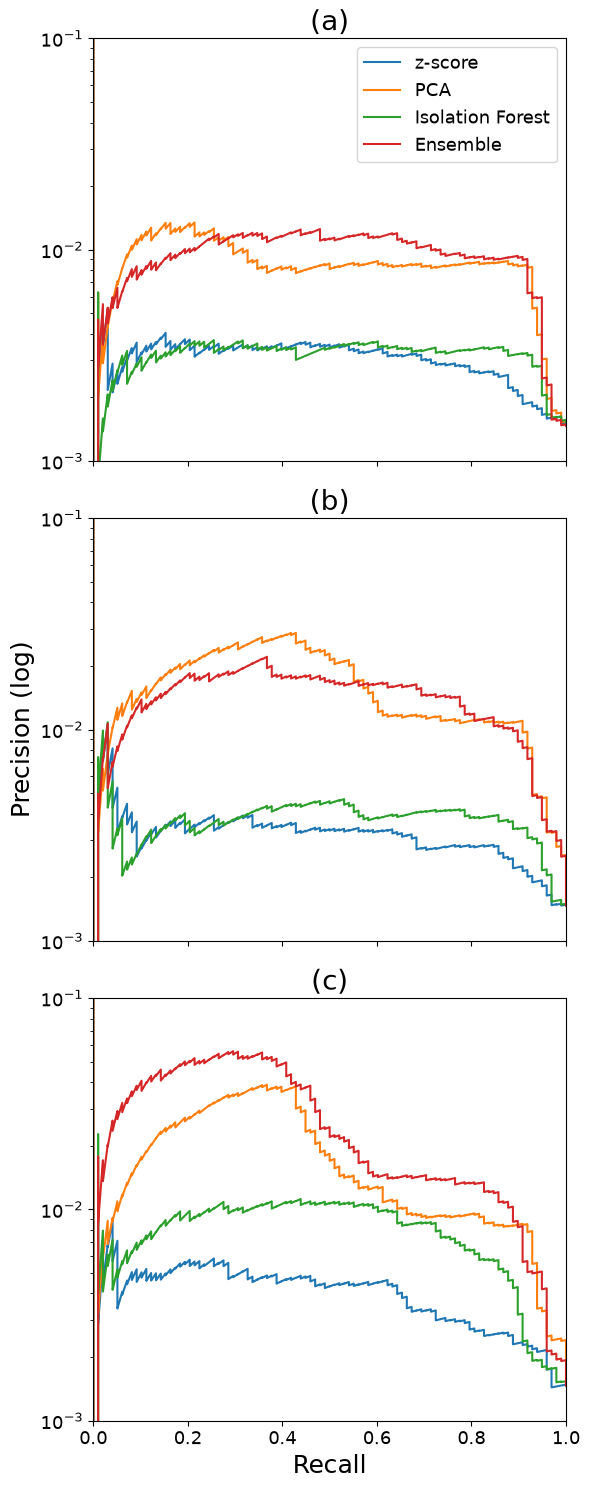

In [28]:
# Create precision-recall curves for each model under each baseline
scorers = {
    "anomaly_score_z":  "z-score",
    "pca_recon_error":  "PCA",
    "iso_forest_score": "Isolation Forest",
    "ensemble_score":   "Ensemble",
}

panels = ["(a)", "(b)", "(c)"] # Initialise panel labels
fig, axes = plt.subplots(3, 1, figsize=(6, 15), sharex=True, sharey=True)

# Loop through each baseline mode, with one subplot per mode
for i, (ax, mode) in enumerate(zip(axes, ["window", "expanding", "global"])):
    df = eval_dfs[mode]
    y_true = df["id"].isin(malicious_ids).astype(int)

    # Loop through each scoring method and plot its precision-recall curve
    for scorer, label in scorers.items():
        y_score = df[scorer].fillna(df[scorer].min())  # Fill NaNs with the lowest score so missing rows rank as least anomalous
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ax.plot(recall, precision, label=label)

    ax.set_xlim(0, 1)
    ax.set_yscale("log")  # Use log precision scale for ease of visualisation
    ax.set_ylim(1e-3, 1e-1)
    if i == 0:
        ax.legend(fontsize=13)
    if i == 1:
        ax.set_ylabel("Precision (log)", fontsize=18)
    if i == 2:
        ax.set_xlabel("Recall", fontsize=18)
    ax.set_title(panels[i], fontsize=20)
    ax.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.show()

## 9. Selected Model Diagnostics - Global Ensemble

In [29]:
# Investigate tiers reached in each baseline for each model
labels = ["baseline_label", "z_baseline_label", "pca_baseline_label", "iso_baseline_label"]
mode_dfs = {
    "window": result_df_z_window,
    "expanding": result_df_z_expanding,
    "global": result_df_z_global,
}

# Loop through each baseline model
for mode, df in mode_dfs.items():
    print("-----", mode, "-----")
    # Loop through each tier label and print the count of each tier used
    for label in labels:
        if label not in df.columns:
            print(f"[{label}: not present]\n")
            continue
        print(df[label].value_counts().to_string(), "\n")

----- window -----
baseline_label
personal_window      61924
dept_window           4492
global_window          287
insufficient_data       40 

z_baseline_label
personal_window      61924
dept_window           4492
global_window          287
insufficient_data       40 

pca_baseline_label
personal_window      61886
dept_window           4490
global_window          287
missing_features        40
insufficient_data       40 

iso_baseline_label
personal_window      61886
dept_window           4490
global_window          287
missing_features        40
insufficient_data       40 

----- expanding -----
baseline_label
personal_expanding    64223
dept_expanding         2240
global_expanding        240
insufficient_data        40 

z_baseline_label
personal_expanding    64223
dept_expanding         2240
global_expanding        240
insufficient_data        40 

pca_baseline_label
personal_expanding    64183
dept_expanding         2240
global_expanding        240
missing_features         40
insu

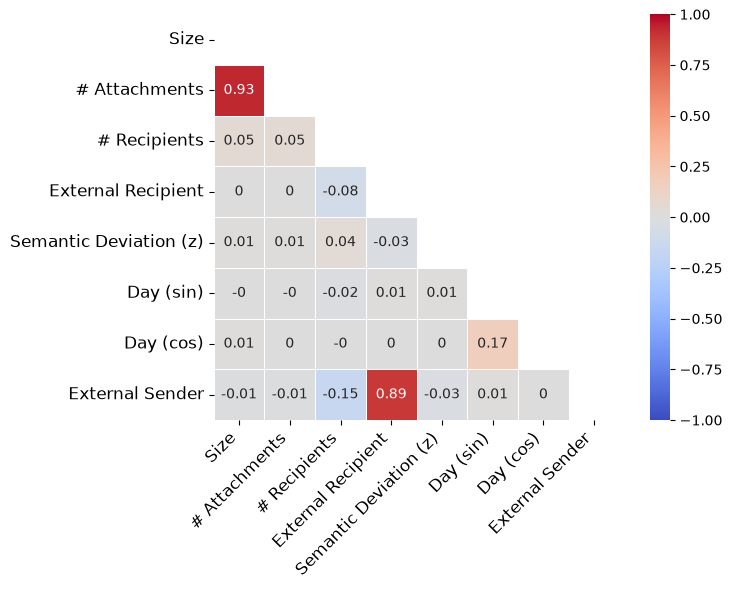

In [13]:
# Analyze feature correlation

# Map feature column names to readable labels for the correlation matrix
feature_labels = {
    "size": "Size",
    "num_attachments": "# Attachments",
    "num_recipients": "# Recipients",
    "external_recipient": "External Recipient",
    "external_sender": "External Sender",
    "day_sin": "Day (sin)",
    "day_cos": "Day (cos)",
    "semantic_deviation_z": "Semantic Deviation (z)"}

corr_features = ["size", "num_attachments", "num_recipients",
                  "external_recipient", "semantic_deviation_z", "day_sin", "day_cos", "external_sender"]
# Drop rows that received NaN scores
clean = result_df_z_global[~result_df_z_global["ensemble_score"].isna()] 
corr = clean[corr_features].corr().round(2)

# Apply readable labels to rows and columns
corr = corr.rename(index=feature_labels, columns=feature_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide the upper triangle for ease of visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.xticks(fontsize=12, rotation=45, ha="right") 
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
# Conduct permutation feature importance on PCA reconstruction error

# Redefine fit_pca so this cell can run without having to rerun fit_pca's original cell
def fit_pca(feats_baseline, n_components):
    scaler = StandardScaler().fit(feats_baseline)
    k = min(n_components, feats_baseline.shape[0], feats_baseline.shape[1])
    pca = PCA(n_components=k).fit(scaler.transform(feats_baseline))
    return scaler, pca

# Select rows that are scored by the model
eval_mask = result_df_z_global["pca_recon_error"].notna().values

# Fit a single scaler/PCA on the clean baseline
clean_df = result_df_z_global[~result_df_z_global["id"].isin(malicious_ids)].dropna(subset=corr_features)
scaler_f, pca_f = fit_pca(clean_df[corr_features].astype(float).values, 5) # Use 5 components as was done when first constructed PCA reconstruction error scores

# Redefine X_all/X_eval/is_mal/y_eval for same reason as fit_pca
X_all = result_df_z_global[corr_features].astype(float).values
X_eval = X_all[eval_mask]
is_mal = result_df_z_global["id"].isin(malicious_ids).values
y_eval = is_mal[eval_mask].astype(int)

# Define function that computes PCA reconstruction error for a feature matrix
def recon(Xa):
        # Xa: feature matrix to score
    Z = scaler_f.transform(Xa)
    return ((Z - pca_f.inverse_transform(pca_f.transform(Z))) ** 2).sum(1)

# Define function that calculates recall among the top k% most anomalous rows by reconstruction error
def rec5(s, k=0.05):
        # s: reconstruction error scores
        # k: top proportion of rows treated flagged
    return y_eval[np.argsort(-s)[:max(1, int(k * len(s)))]].sum() / y_eval.sum()

# Calculate baseline recall at 5% cut-off with unshuffled features
base = rec5(recon(X_eval))
rng = np.random.default_rng(123) # Fixed seed for reproducible shuffles
n_rep = 25 # Number of shuffle repeats per feature, to average out noise

# Shuffle one column at a time, calculate how much recall at 5% cut-off drops by
rows = {}
for j, c in enumerate(corr_features):  # Loop through each feature
    d = []
    for _ in range(n_rep):
        Xp = X_eval.copy()
        Xp[:, j] = X_eval[rng.permutation(len(X_eval)), j]
        d.append(base - rec5(recon(Xp)))
    rows[c] = (np.mean(d), np.std(d))  # Record mean and standard deviation drop in recall for this feature

pfi = pd.DataFrame(rows, index=["mean", "std"]).T.sort_values("mean", ascending=False)
print("per-feature drop in recall at 5% cut-off\n", pfi.round(4))

per-feature drop in recall at 5% cut-off
                         mean     std
external_recipient    0.3682  0.0347
size                  0.3571  0.0196
num_attachments       0.3420  0.0181
day_cos               0.3184  0.0383
external_sender       0.2759  0.0359
day_sin               0.2041  0.0544
num_recipients        0.0037  0.0095
semantic_deviation_z -0.0008  0.0081


In [32]:
# Conduct permutation feature important on isolation forest

# Redefine clean_feats for same reason as fit_pca in above cell
clean_feats = clean_df[corr_features].astype(float).values
# Fit a single scaler/isolation forest on the clean baseline
scaler_if = StandardScaler().fit(clean_feats)
iforest_f = IsolationForest(n_estimators=100, random_state=123).fit(scaler_if.transform(clean_feats)) # # Use 100 trees as was done when first constructed isolation forest scores

# Define function that calculates isolation forest anomaly score for a feature matrix
def if_score(Xa):
    # Xa: feature matrix to score
    return -iforest_f.score_samples(scaler_if.transform(Xa))   # Negate so that higher = more anomalous

# Calculate baseline recall at 5% cut-off with unshuffled features
base_if = rec5(if_score(X_eval))
rng = np.random.default_rng(123)

# Shuffle one column at a time, calculate how much recall at 5% cut-off drops by
rows = {}
for j, c in enumerate(corr_features):  # Loop through each feature
    d = []
    for _ in range(n_rep): # Use same n_rep as for PCA (25)
        Xp = X_eval.copy()
        Xp[:, j] = X_eval[rng.permutation(len(X_eval)), j]
        d.append(base_if - rec5(if_score(Xp)))
    rows[c] = (np.mean(d), np.std(d))  # Record mean and standard deviation drop in recall for this feature

pfi_if = pd.DataFrame(rows, index=["mean", "std"]).T.sort_values("mean", ascending=False)
print("per-feature drop in recall at 5% cut-off\n", pfi_if.round(4))

per-feature drop in recall at 5% cut-off
                         mean     std
external_recipient    0.0963  0.0171
external_sender       0.0669  0.0096
semantic_deviation_z  0.0412  0.0154
size                  0.0355  0.0258
num_recipients       -0.0139  0.0163
day_cos              -0.0143  0.0138
num_attachments      -0.0257  0.0229
day_sin              -0.0282  0.0283


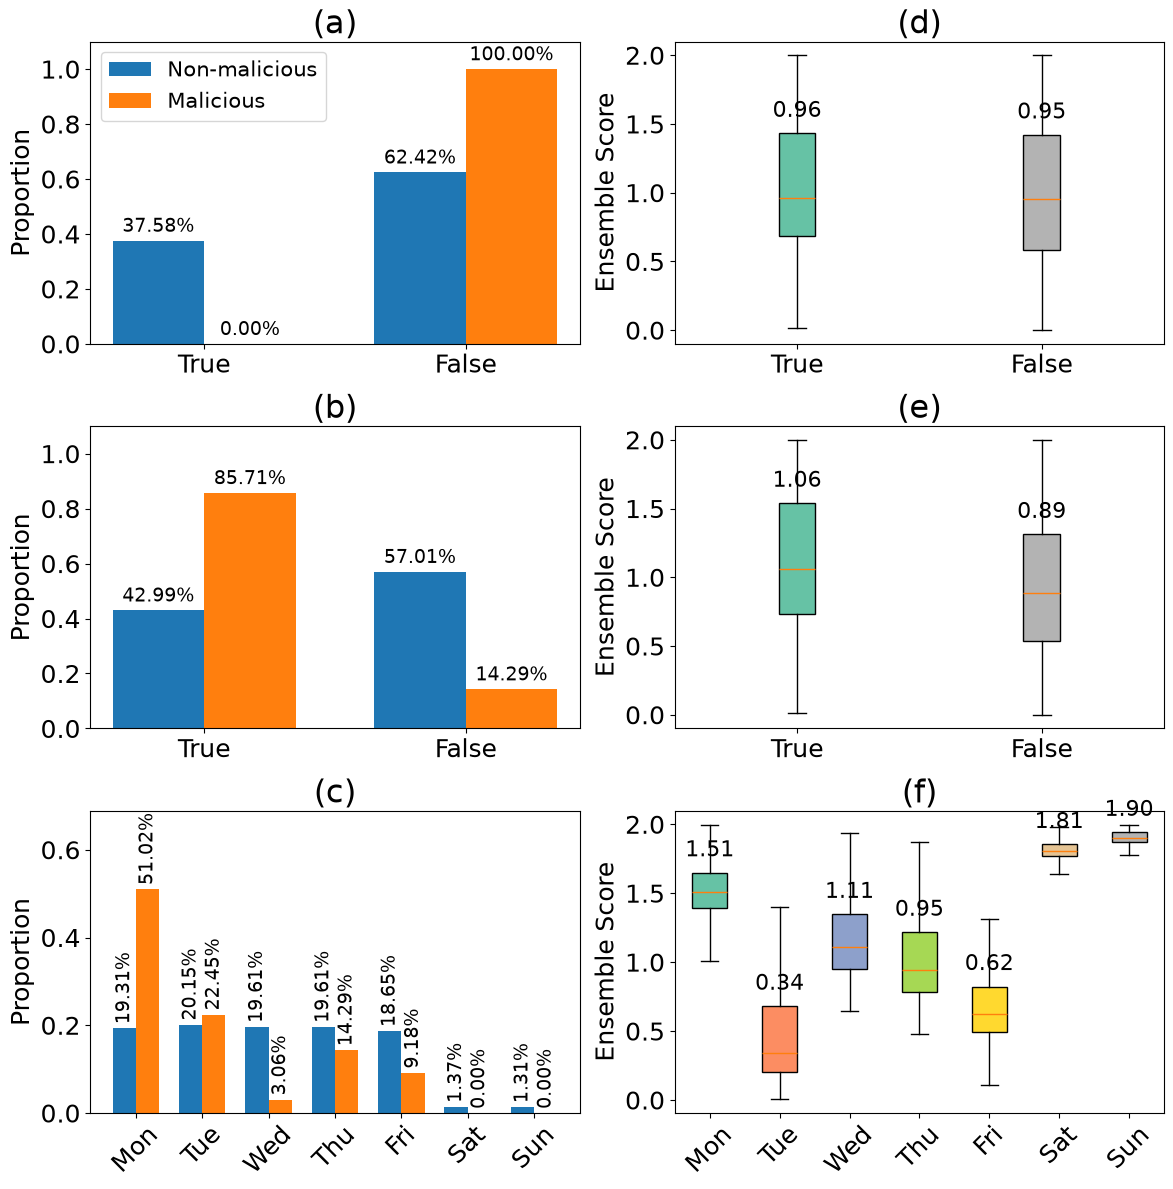

In [10]:
# Visualise observed and scored by if email is malicious for each categorical feature

# Specify malicious and non-malicious data
non_malicious_df = result_df_z_window[~result_df_z_window["id"].isin(malicious_ids)].copy()
malicious_df = result_df_z_window[result_df_z_window["id"].isin(malicious_ids)].copy()

# Only keep rows the ensemble actually scored
feature_df = result_df_z_global[~result_df_z_global["ensemble_score"].isna()]

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_abbrev = {"Monday": "Mon", "Tuesday": "Tue", "Wednesday": "Wed",
              "Thursday": "Thu", "Friday": "Fri", "Saturday": "Sat", "Sunday": "Sun"}
categorical_features = ["external_sender", "external_recipient", "day_of_week"]

# One row per feature, two columns - proportion bar chart and ensemble score box plot
n = len(categorical_features)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
if n == 1:
    axes = axes.reshape(1, 2)
left_labels = ["(a)", "(b)", "(c)"]
right_labels = ["(d)", "(e)", "(f)"]

for i, feat in enumerate(categorical_features):
    if feat == "day_of_week":
        categories = day_order
        display_labels = [day_abbrev[c] for c in categories]
    else:
        categories = [True, False]
        display_labels = [str(c) for c in categories]

    # Left column - proportion bar chart
    ax_bar = axes[i, 0]
    non_mal_counts = non_malicious_df[feat].value_counts(normalize=True).reindex(categories, fill_value=0)
    mal_counts = malicious_df[feat].value_counts(normalize=True).reindex(categories, fill_value=0)
    x = np.arange(len(categories))
    width = 0.35
    bars1 = ax_bar.bar(x - width/2, non_mal_counts.values, width, label="Non-malicious")
    bars2 = ax_bar.bar(x + width/2, mal_counts.values, width, label="Malicious")
    for bars in (bars1, bars2):
        for bar in bars:
            height = bar.get_height()
            ax_bar.annotate(f"{height:.2%}",
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3), textcoords="offset points",
                             ha="center", va="bottom", fontsize=14,
                             rotation=90 if feat == "day_of_week" else 0)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(display_labels,
                            rotation=45 if feat == "day_of_week" else 0)
    ax_bar.set_ylabel("Proportion", fontsize=18)
    ax_bar.set_title(left_labels[i], fontsize=23)
    if feat == "day_of_week":
        max_height = max(non_mal_counts.max(), mal_counts.max())
        ax_bar.set_ylim(0, max_height * 1.35)
    else:
        ax_bar.set_ylim(0, 1.1)
    ax_bar.tick_params(axis="both", labelsize=18)
    if i == 0:
        ax_bar.legend(fontsize=15)

    # Right column - ensemble score box plot
    ax_box = axes[i, 1]
    data = [feature_df.loc[feature_df[feat] == cat, "ensemble_score"].dropna() for cat in categories]
    bp = ax_box.boxplot(data, showfliers=False, patch_artist=True)
    colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax_box.set_xticks(range(1, len(categories) + 1))
    ax_box.set_xticklabels(display_labels,
                            rotation=45 if feat == "day_of_week" else 0)
    ax_box.set_ylabel("Ensemble Score", fontsize=18)
    ax_box.set_title(right_labels[i], fontsize=23)
    ax_box.tick_params(axis="both", labelsize=18)
    for j, d in enumerate(data):
        median_val = np.median(d)
        q3_val = np.percentile(d, 75)
        ax_box.annotate(f"{median_val:.2f}",
                         xy=(j + 1, q3_val),
                         xytext=(0, 8), textcoords="offset points",
                         ha="center", va="bottom", fontsize=16)

plt.tight_layout()
plt.show()

In [34]:
# Calculate observed continuous feature summary stats by malicious and non-malicuous emails

continuous_features = ["size", "num_attachments", "num_recipients", "semantic_deviation_z"]

summary_rows = []
# Loop through each feature
for feat in continuous_features:
    # Loop through each type of dataframe, malicious and non-malicious
    for label, df_subset in [("Non-malicious", non_malicious_df), ("Malicious", malicious_df)]:
        vals = df_subset[feat].dropna() # Disclude NaN values from calculation
        # Summary stats per feature, split by malicious vs non-malicious
        summary_rows.append({
            "feature": feat,
            "group": label,
            "mean": vals.mean(),
            "median": vals.median(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
        })
        
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

             feature         group         mean        median          std          min          max
                size Non-malicious 3.907583e+05  31925.000000 9.921258e+05  7972.000000 1.305774e+07
                size     Malicious 1.181786e+06 809778.000000 1.460245e+06 15188.000000 7.007912e+06
     num_attachments Non-malicious 4.109236e-01      0.000000 1.051553e+00     0.000000 9.000000e+00
     num_attachments     Malicious 1.285714e+00      1.000000 1.428719e+00     0.000000 9.000000e+00
      num_recipients Non-malicious 2.321059e+00      2.000000 1.351903e+00     1.000000 7.000000e+00
      num_recipients     Malicious 1.377551e+00      1.000000 1.869535e+00     1.000000 1.800000e+01
semantic_deviation_z Non-malicious 2.810398e-01      0.261789 1.060948e+00    -2.990256 4.905293e+00
semantic_deviation_z     Malicious 1.478524e+00      1.785061 1.042367e+00    -1.080992 3.730224e+00


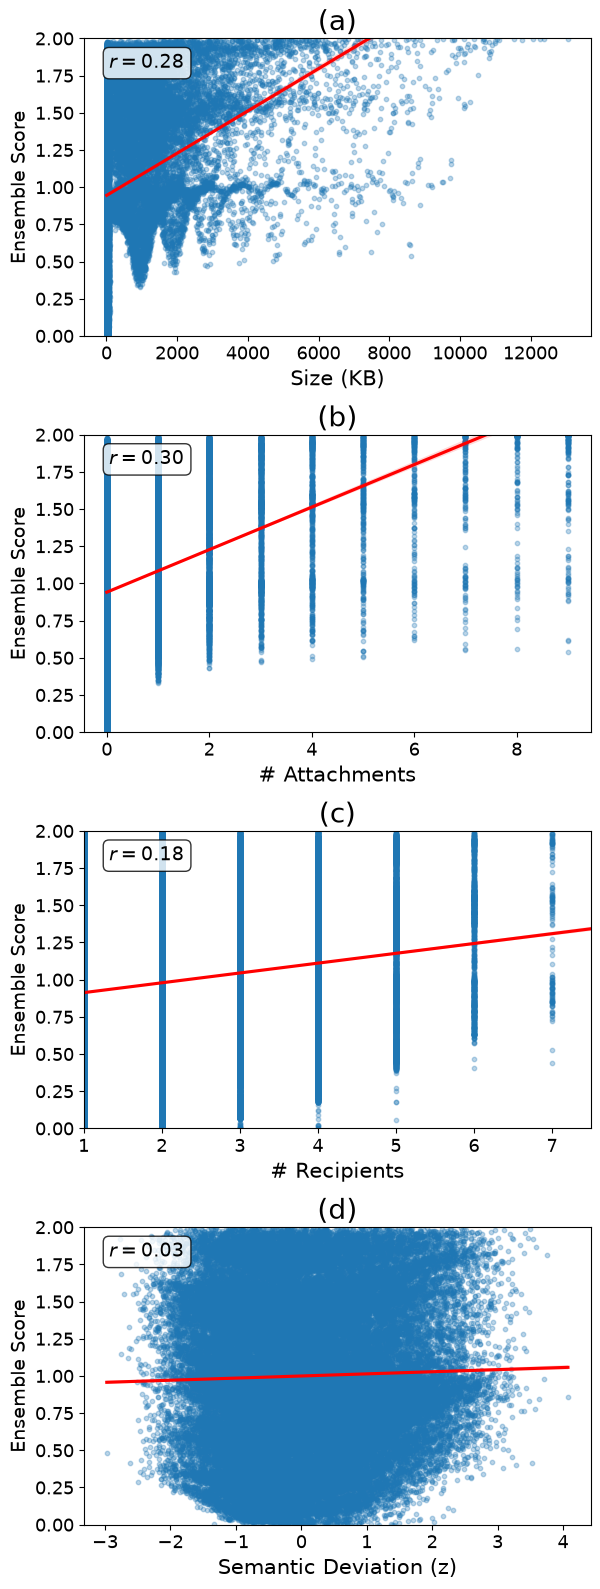

In [27]:
# Visualise observed continuous features and their corresponding ensemble scores

# Convert size (bytes) to kilobytes for ease of visualisation
feature_df["size_kb"] = feature_df["size"] / 1000
continuous_features = ["size_kb", "num_attachments", "num_recipients", "semantic_deviation_z"]
# Specify x-axis labels
xlabel_map = {
    "size_kb": "Size (KB)",
    "num_attachments": "# Attachments",
    "num_recipients": "# Recipients",
    "semantic_deviation_z": "Semantic Deviation (z)",
}

# One subplot per feature - scatter and regression line vs ensemble score
n = len(continuous_features)
fig, axes = plt.subplots(n, 1, figsize=(6, 4 * n))
if n == 1:
    axes = [axes]
subplot_labels = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, feat) in enumerate(zip(axes, continuous_features)):
    valid = feature_df[[feat, "ensemble_score"]].dropna()
    # Calculate Pearson correlation between the feature and the ensemble score
    r, p = pearsonr(valid[feat], valid["ensemble_score"])
    sns.regplot(data=feature_df, x=feat, y="ensemble_score",
                scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"}, ax=ax)
    ax.set_title(subplot_labels[i], fontsize=20)
    ax.set_xlabel(xlabel_map[feat], fontsize=15)
    ax.set_ylabel("Ensemble Score", fontsize=14)
    ax.tick_params(axis="both", labelsize=13)
    ax.annotate(f"$r = {r:.2f}$",
                xy=(0.05, 0.95), xycoords="axes fraction",
                ha="left", va="top", fontsize=14,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.set_ylim(0, 2)
    if feat == "size":
        ax.set_ylim(0, 2)
    if feat == "num_recipients":
        ax.set_xlim(1, 7.5)

plt.tight_layout()
plt.show()

In [29]:
# Evaluate model's perfomance by type of malicious act (scenario)

# Add scenario information to each malicious email
feature_df["scenario"] = feature_df["id"].map(malicious_scenario)

# Calculate recall by scenario for each cut-off
def evaluate_by_scenario(df, score_type="ensemble_score", pcts=(0.01, 0.05, 0.10)):
    d = df[df[score_type].notna()].copy()
    d_sorted = d.sort_values(score_type, ascending=False).reset_index(drop=True)
    totals = d_sorted["scenario"].value_counts().sort_index()
    print(f"malicious scored by scenario:\n{totals.to_string()}\n") # Record number of malicious emails in each scenario
    rows = []
    # Loop through each of our three cut-offs
    for pct in pcts:
        cutoff_n = max(1, int(len(d_sorted) * pct))
        top_k = d_sorted.iloc[:cutoff_n]
        detected = top_k["scenario"].value_counts()
        # Loop through each scenario
        for s in totals.index:
            n_det = int(detected.get(s, 0))
            rows.append({
                "cutoff": f"{pct:.0%}",
                "scenario": int(s),
                "detected": n_det,
                "total": int(totals[s]),
                "recall": n_det / totals[s]})
        # Add a combined row across all scenarios for this cutoff
        n_det_all = int(top_k["scenario"].notna().sum())
        rows.append({
            "cutoff": f"{pct:.0%}",
            "scenario": "all",
            "detected": n_det_all,
            "total": int(totals.sum()),
            "recall": n_det_all / totals.sum()}) # Record recall by cut-off and scenario
    return pd.DataFrame(rows)

res = evaluate_by_scenario(feature_df)
print(res.pivot(index="scenario", columns="cutoff", values="recall").round(4))

malicious scored by scenario:
scenario
2.0    13
3.0    15
4.0    70

cutoff        1%     10%      5%
scenario                        
2         0.0000  0.6923  0.2308
3         0.0000  0.2000  0.1333
4         0.5000  0.9857  0.7286
all       0.3571  0.8265  0.5714


In [30]:
# Uncertainty quantification around recall via bootstrap

# Select feature columns used to construct ensemble
score_cols = ["pca_recon_error", "iso_forest_score"]
pcts = [0.01, 0.05, 0.10]
malicious_ids_arr = np.array(list(malicious_ids))

# Specify weights used by ensemble
best_weights = {"pca_recon_error": 1.5, 'iso_forest_score': 0.5}

df = result_df_z_global.copy()
df = df[df[score_cols].notna().all(axis=1)].copy()   # Disclude rows without a score

# Combine both scores into one ensemble score via weighted percentile rank
ranks = df[score_cols].rank(pct=True)
df["ensemble_score"] = sum(ranks[c] * w for c, w in best_weights.items())

# Sort all rows by ensemble score and retain only scoreable malicious rows
order = df.sort_values("ensemble_score", ascending=False).reset_index(drop=True)
mal_present = malicious_ids_arr[np.isin(malicious_ids_arr, df["id"].values)]
n = len(mal_present)

rng = np.random.default_rng(123)
B = 2000  # Specify number of bootstrap resamples
# Loop through each cutoff
for pct in pcts:
    # Take the top pct% of rows by ensemble score
    cutoff_n = max(1, int(len(order) * pct))
    topk_ids = set(order.iloc[:cutoff_n]["id"])
    # Flag which malicious emails fall inside that top-k set
    flagged = np.isin(mal_present, list(topk_ids))       # True/False for each malicious email: was it flagged?
    # Resample malicious emails with replacement, B times, to build a distribution of recall values
    idx = rng.integers(0, n, size=(B, n))
    boot = flagged[idx].mean(axis=1)   # Calculate recall for each bootstrap resample
    lo, hi = np.percentile(boot, [2.5, 97.5])  # 95% confidence interval bounds
    print(f"{pct:>4.0%} cut-off: recall {flagged.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

  1% cut-off: recall 0.3571  95% CI [0.2653, 0.4490]
  5% cut-off: recall 0.5714  95% CI [0.4694, 0.6633]
 10% cut-off: recall 0.8265  95% CI [0.7449, 0.8980]


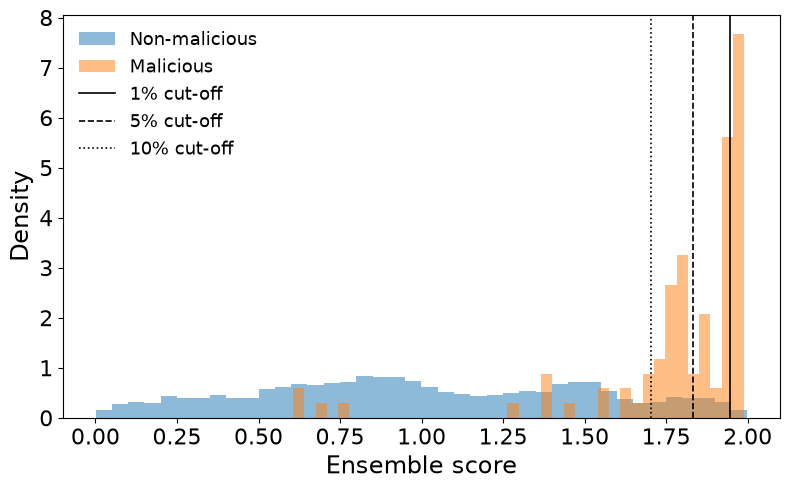

In [18]:
# Look into how well-separated are malicious and non-malicious emails by our ensemble score

df = result_df_z_global.copy()
is_mal = df["id"].isin(malicious_ids)

# Overlay density histograms of ensemble score, malicious vs non-malicious
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df.loc[~is_mal, "ensemble_score"], bins=40, alpha=0.5,
        density=True, label="Non-malicious") # Specify density=TRUE for unit normalisation
ax.hist(df.loc[is_mal, "ensemble_score"], bins=40, alpha=0.5,
        density=True, label="Malicious")

# Mark top each of our cuto-ffs as vertical lines
for pct, ls in [(0.99, "-"), (0.95, "--"), (0.90, ":")]:
    cut = df["ensemble_score"].quantile(pct)
    ax.axvline(cut, color="black", lw=1.2, ls=ls,
               label=f"{100 * (1 - pct):.0f}% cut-off")

ax.set_xlabel("Ensemble score", fontsize=17)
ax.set_ylabel("Density", fontsize=17)
ax.tick_params(labelsize=16)
ax.legend(fontsize=13, frameon=False)
plt.tight_layout()
plt.show()